<a href="https://colab.research.google.com/github/Marius-Suteu/MAD-UMFST-Grupa2-Suteu-Marius-Laborator1/blob/main/Laborator1_MIB2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import random
import string

# Exemplu de tinta
target = "mib2025"
target_length = len(target)

# Alfabetul permis
alphabet = string.ascii_lowercase + string.digits


def count_position_matches(guess, target=target):
    """Returneaza numarul caracterelor corecte aflate pe pozitia corecta."""

    matches = 0

    for g, t in zip(guess, target):
        if g == t:
            matches += 1

    return matches



def mutate_one_index(solution, alphabet=alphabet):
    """Returneaza o copie a sirului in care un singur caracter a fost modificat."""

    # Index aleator
    index = random.randint(0, len(solution) - 1)

    # Convertire sir in lista
    mutated = list(solution)

    # Caracter nou
    new_char = random.choice(alphabet)

    # Inlocuire caracter
    mutated[index] = new_char

    # Reconstruire sir
    return "".join(mutated)



def mutate_with_probability(solution, mutation_probability, alphabet=alphabet):
    """Returneaz o copie a sirului in care fiecare caracter poate fi modificat cu o probabilitate data."""

    mutated = list(solution)

    for i in range(len(mutated)):
        if random.random() < mutation_probability:
            mutated[i] = random.choice(alphabet)

    return "".join(mutated)

# TESTE

assert count_position_matches(target, target) == target_length
assert len(mutate_one_index(target)) == target_length
assert len(mutate_with_probability(target, 0.2)) == target_length

print("Toate testele au trecut cu succes!")

# Exemple de rulare
print("Fitness:", count_position_matches("mib2000", target))
print("Mutatie un index:", mutate_one_index(target))
print("Mutatie probabilistica:", mutate_with_probability(target, 0.3))

Toate testele au trecut cu succes!
Fitness: 5
Mutatie un index: mibh025
Mutatie probabilistica: m3b20r5


Timp de rulare: 0:00:00.231018
Histograma: [41079  8152   749    18     2     0     0     0]


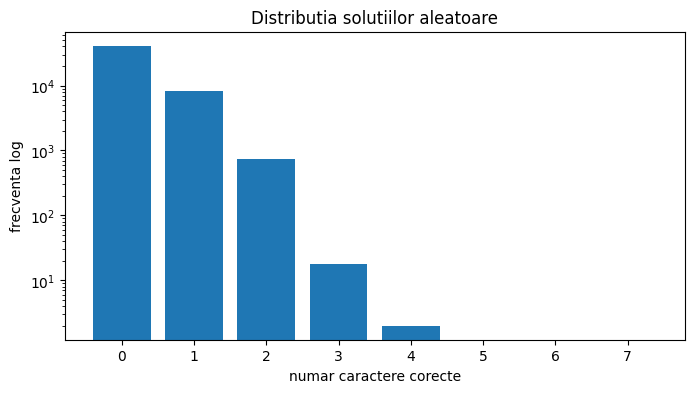

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
import random
import string

# Setari initiale
target = "mib2025"
target_length = len(target)
alphabet = string.ascii_lowercase + string.digits

# Genereaza string random
def generate_random_string(length, alphabet):
    return "".join(random.choice(alphabet) for _ in range(length))

# Fitness
def count_position_matches(guess, target=target):
    matches = 0

    for g, t in zip(guess, target):
        if g == t:
            matches += 1

    return matches

RUN_EXERCISE_1A = True

if RUN_EXERCISE_1A:
    n_samples = 50_000

    histogram = np.zeros(target_length + 1, dtype=int)

    start_time = datetime.datetime.now()

    for _ in range(n_samples):
        candidate = generate_random_string(target_length, alphabet)

        score = count_position_matches(candidate, target)

        histogram[score] += 1

    elapsed = datetime.datetime.now() - start_time

    print(f"Timp de rulare: {elapsed}")
    print("Histograma:", histogram)

    plt.figure(figsize=(8, 4))

    plt.bar(range(target_length + 1), histogram)

    plt.yscale("log")

    plt.xlabel("numar caractere corecte")
    plt.ylabel("frecventa log")
    plt.title("Distributia solutiilor aleatoare")

    plt.show()

In [18]:
# Mutatie pe un singur index
def mutate_one_index(solution, alphabet=alphabet):

    index = random.randint(0, len(solution) - 1)

    mutated = list(solution)

    mutated[index] = random.choice(alphabet)

    return "".join(mutated)


# Mutatie probabilistica
def mutate_with_probability(solution, mutation_probability, alphabet=alphabet):

    mutated = list(solution)

    for i in range(len(mutated)):

        if random.random() < mutation_probability:
            mutated[i] = random.choice(alphabet)

    return "".join(mutated)


# Hill climbing cu un singur index
def hill_climb_string_one_index(max_iterations=50_000):

    current = generate_random_string(target_length, alphabet)

    current_score = count_position_matches(current)

    best = current
    best_score = current_score

    for _ in range(max_iterations):

        candidate = mutate_one_index(current)

        candidate_score = count_position_matches(candidate)

        # Accepta daca nu scade fitness-ul
        if candidate_score >= current_score:

            current = candidate
            current_score = candidate_score

        if current_score > best_score:

            best = current
            best_score = current_score

        # Stop daca e gasita solutia perfecta
        if best_score == target_length:
            break

    return best, best_score


# Hill climbing cu probabilitate
def hill_climb_string_probability(
    max_iterations=50_000,
    mutation_probability=0.1
):

    current = generate_random_string(target_length, alphabet)

    current_score = count_position_matches(current)

    best = current
    best_score = current_score

    for _ in range(max_iterations):

        candidate = mutate_with_probability(
            current,
            mutation_probability
        )

        candidate_score = count_position_matches(candidate)

        if candidate_score >= current_score:

            current = candidate
            current_score = candidate_score

        if current_score > best_score:

            best = current
            best_score = current_score

        if best_score == target_length:
            break

    return best, best_score


RUN_EXERCISE_1B = True

if RUN_EXERCISE_1B:

    best_one = hill_climb_string_one_index()

    best_prob = hill_climb_string_probability(
        mutation_probability=0.1
    )

    print("Rezultat un index:")
    print(best_one)

    print()

    print("Rezultat probabilistic:")
    print(best_prob)

Rezultat un index:
('mib2025', 7)

Rezultat probabilistic:
('mib2025', 7)


In [17]:
# Exercitiul 2

import numpy as np
import matplotlib.pyplot as plt

SEED = 42

# FUNCTIA SPHERE

def sphere(x):

    x = np.asarray(x)

    return np.sum(x ** 2)

# FUNCTIA ACKLEY

def ackley(x):

    x = np.asarray(x)

    a = 20
    b = 0.2
    c = 2 * np.pi

    d = len(x)

    sum_sq = np.sum(x ** 2)

    sum_cos = np.sum(np.cos(c * x))

    term1 = -a * np.exp(-b * np.sqrt(sum_sq / d))

    term2 = -np.exp(sum_cos / d)

    return term1 + term2 + a + np.e

# RANDOM SEARCH

def random_search_2d(func, bounds, n_evals=20, rng=None):

    if rng is None:
        rng = np.random.default_rng()

    trajectory = []

    for _ in range(n_evals):

        point = np.array([
            rng.uniform(bounds[0][0], bounds[0][1]),
            rng.uniform(bounds[1][0], bounds[1][1])
        ])

        value = func(point)

        trajectory.append((point, value))

    return trajectory

# HILL CLIMBING

def hill_climb_2d(
    func,
    bounds,
    n_evals=20,
    step_sigma=0.4,
    rng=None
):

    if rng is None:
        rng = np.random.default_rng()

    current = np.array([
        rng.uniform(bounds[0][0], bounds[0][1]),
        rng.uniform(bounds[1][0], bounds[1][1])
    ])

    current_value = func(current)

    trajectory = [(current.copy(), current_value)]

    for _ in range(n_evals - 1):

        candidate = current + rng.normal(0, step_sigma, size=2)

        # limitare in bounds
        candidate[0] = np.clip(
            candidate[0],
            bounds[0][0],
            bounds[0][1]
        )

        candidate[1] = np.clip(
            candidate[1],
            bounds[1][0],
            bounds[1][1]
        )

        candidate_value = func(candidate)

        if candidate_value < current_value:

            current = candidate
            current_value = candidate_value

        trajectory.append((current.copy(), current_value))

    return trajectory

# PLOT 3D

def plot_trajectory_3d(func, bounds, trajectory, title):

    xs = [p[0][0] for p in trajectory]
    ys = [p[0][1] for p in trajectory]
    zs = [p[1] for p in trajectory]

    fig = plt.figure(figsize=(8, 6))

    ax = fig.add_subplot(111, projection='3d')

    ax.plot(xs, ys, zs, marker='o')

    ax.set_title(title)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("f(x,y)")

    plt.show()